<a href="https://colab.research.google.com/github/chewanna7-code/NatureInsightStudy/blob/main/Trade_Off_Support_Matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NatureInsight vs Literature Trade-Off Matrix

This notebook compares NatureInsight-derived intervention scores against literature-informed benchmark scores.



The workflow is intended for Nature-Based Solution (NbS) decision support where flood storage, habitat, carbon, cost, delivery risk, policy alignment and disservices need to be compared. Literature studies revealed the challenges of trade-offs within decision making for NbS, and the intention is this matrix can extend NatureInsight to support this next stage.

The intention is the matrix could be used in a proposal germinating from this study. BRITE- NI ie Budget-Responsive Intervention and Trade-off Evaluator — NatureInsight (add-on). This proposal uses the NatureInsight model but originates from a constrained budget prior to the display, and it also integrates the use of this trade off.

Initially, I was trying to weigh up trade-offs for my own outcomes, however, I realised the value this could add to decision-support tools and implementation. This, and literature, inspired this notebook.


The notebook asks for rankings, which using AHP and Pairwise comparison, creates a weighting and score, to ultimately display strengths and relations. The output is a clear table, coloured to reflect the italian flag convension. This is inspired and translated into simplified approach in my study, whereby the colours represent a strong or weak relationship, while convoluted outcome is also marked. The table compares NatureInsight to Literature, to understand strengths and correlation, per intervention, and per category.

# Trade-Off Support Tool

This notebook implements a flexible framework using multiple pathways to allow flexibility of:
- Weighted scoring
- Analytical Hierarchy Process (AHP)
- User-defined or preset weightings

The tool is designed to:
- Support decision-making for Nature-Based Solutions (NbS)
- Allow comparison between scenarios
- Highlight trade-offs between competing objectives
Highlight conflcits of interest between the tool and literature and studies

Outputs of graphs and tables are designed to support the decision-making process and evalaute trade-offs, both of which are raised as industry wide challenges.




*Operational cells below, please refer to Step 1*

In [1]:
# Import libraries into python to to support onward function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import io

In [2]:
# Create simple print functions to improve readability for user
def print_title(title):
  #Prints a main title
    print("\n" + "="*60)
    print(title)
    print("="*60)

def print_subtitle(subtitle):
  #prints a formatted subtitle
    print("\n" + "-"*60)
    print(subtitle)
    print("-"*60)

def print_note(text):
  """Prints a simple note for user guidance."""
  print(f"\nNote: {text}")

# Can alter Criteria if necessary here:

These criteria are used to evaluate each intervention, designed to reflect environmental beenfits, economic factors and feasibility.

These criteria form the basis of the AHP weighting generation, and will be compared to create pairwise outcomes.

In [3]:
#Define criteria to be evaluated
#If these are altered, ensure consistency with formating and names used, trhoughout the code.

criteria = [
    "Storage",
    "Habitat",
    "Carbon",
    "Cost",
    "Cost Effectiveness", # Corrected from "Cost-Effectiveness" to match standardized alias
    "Time to Effectiveness",
    "Durability",
    "Stakeholder Risk",
    "Policy Alignment",
    "Disservices Risk"
]

# **Start Here: Select a route**
This will depend on your preferences, and resources available.

**Step 1: Please chose a weighting route**

There are three options for routes:

1. **Preset weighting**  
   Uses predefined stakeholder-style priorities.

2. **Upload weighting or pairwise matrix**  
   Allows an upload of saved CSV file.

3. **Create a new AHP matrix**  
   Builds a new pairwise comparison matrix interactively in Python.

The output from this section is a single weighting vector called `weights`, which is then used throughout the rest of the analysis to evalaute your trade-offs.

Re-run the cell below if seeking to change route

In [4]:
# Displays a message to allow route selection
# will show and explain the three route options

print_subtitle("Step 1: Select a weighting route")

route = input(
    "Write '1' for using a stakeholder-specific preset, '2' for upload of your own pre-made pairwise or weighting, or '3' to create a new AHP within python: "
).strip()

# Initialize matrix to None, as it might not be defined by all routes
matrix = None

if route == "1":
    print("\nPreset AHP selected.")
elif route == "2":
    print("\nUpload route selected.")
elif route == "3":
    print("\nCreate a new AHP selected.") #these are the route options
else:
    raise ValueError("Invalid selection. Please rerun and enter 1, 2, or 3.")


------------------------------------------------------------
Step 1: Select a weighting route
------------------------------------------------------------
Write '1' for using a stakeholder-specific preset, '2' for upload of your own pre-made pairwise or weighting, or '3' to create a new AHP within python: 2

Upload route selected.


In [5]:
# Step 2A: Preset selection route chosen
# next step is to then chose which preset

if route == "1":
    print_subtitle("Step 2A: Choose preset weighting")

    print("1 - Flood-focused")
    print("2 - Carbon-Focussed")
    print("3 - Habitat-Focussed")
    print("4 - Cost-Focussed")
    print("5 - Policy-Focussed")
    print("6 - Land-Owner Perspective")
    print("For a multi-benefit approach determining AHP within this tool is recommended, as it still remains highly perception determined. Re-run the previous cell.")


    preset = input("Enter 1, 2, 3, 4, 5, 6: ").strip()

    if preset == "1":
        weights = np.array([0.1439, 0.07613, 0.0383, 0.0710, 0.0999, 0.0235, 0.1193, 0.1402, 0.123, 0.1645])
        print("\nloaded")

    elif preset == "2": #use of elif allows for conditional outcomes
        weights = np.array([0.0589, 0.0834, 0.2546, 0.0627, 0.0972, 0.0538, 0.1385, 0.0569, 0.1243, 0.0697])
        print("\nCarbon-focused preset loaded")

    elif preset == "3":
        weights = np.array([0.0728, 0.1784, 0.0183, 0.0336, 0.1448, 0.04886, 0.1489, 0.0486, 0.0754, 0.02302])
        print("\nloaded")

    elif preset == "4":
        weights = np.array([0.1922, 0.0205, 0.0224, 0.2499, 0.3035, 0.1225, 0.1345, 0.0289, 0.0623, 0.00363])
        print("\nloaded")

    elif preset == "5":
        weights = np.array([0.1018, 0.0826, 0.0879, 0.0784, 0.0967, 0.0795, 0.1432, 0.1186, 0.1689, 0.0424])
        print("\nPolicy-focused preset loaded")

    elif preset == "6":
        weights = np.array([0.0583, 0.0521, 0.0442, 0.1587, 0.1789, 0.1184, 0.1127, 0.1526, 0.0675, 0.0566])
        print("\nLand-owner perspective preset loaded")

    else: # fall back display to support error diagnostic for user
        raise ValueError("Invalid preset choice")

## Step 2: Proceed with Uploading an AHP.



This is particualarly helpful for repeated inputs of daat for evaluation, speeding up the process.

Two formats are supported:
- A weighting vector (CSV with Criterion + Weight)
- A full AHP pairwise comparison matrix

If a AHP matrix is used, weightings will be calculated through built in functions

In [6]:
# Step 2B: Upload existing data


if route == "2":
    print_subtitle("Step 2B: Upload weighting or pairwise matrix") #added for clarity

    from google.colab import files
    import io

    print("1 - Upload weighting file")
    print("2 - Upload pairwise matrix")

    upload_type = input("Enter 1 or 2: ").strip() #provides an option box before next stage, this informs the code what processing is required next

    print("\nPlease upload your file:")
    uploaded = files.upload() # allows easy file upload

    # Get uploaded file name
    filename = list(uploaded.keys())[0]

    if upload_type == "1":
        df_weights = pd.read_csv(io.BytesIO(uploaded[filename]))
        weights = df_weights["Weight"].values

        print("\nWeights successfully loaded from uploaded file")

    elif upload_type == "2":
        df_matrix = pd.read_csv(io.BytesIO(uploaded[filename]), index_col=0)
        matrix = df_matrix.values

        # Calculate weights from matrix if a matrix file was input
        col_sum = np.sum(matrix, axis=0)
        norm_matrix = matrix / col_sum
        weights = np.mean(norm_matrix, axis=1)

        print("\nPairwise matrix uploaded and weights calculated")

    else:
        raise ValueError("Invalid upload option")


------------------------------------------------------------
Step 2B: Upload weighting or pairwise matrix
------------------------------------------------------------
1 - Upload weighting file
2 - Upload pairwise matrix
Enter 1 or 2: 2

Please upload your file:


Saving anna2_pairwise_matrix.csv to anna2_pairwise_matrix.csv

Pairwise matrix uploaded and weights calculated


AHP process written below for clarity and readability.
# **Create new AHP** AlTERNATIVE OPTION

In [7]:

# Step 2C: Create new AHP

print_note("You will be asked to compare all criteria pairs.")


if route == "3":
    print_subtitle("Step 2C: Create a new AHP")


    n = len(criteria)

    # form a matrix

    matrix = np.ones((n, n)) # n = criteria number
    skipped = [] #for any skipped outputs


    # Input conversion function from before

    def convert_input(value):
        if value == "c": #equal values are given c
            return 1 #when equal, a value of 1 is given
        try:
            val = int(value)
            if val > 0:
                return val
            elif val < 0: #this explains the ranking process for whether scenario A or B is more important, negative values are used for scale

                return 1 / abs(val) # absolute value
        except:
            return None #if the input is invalid, none will be returned, again, support diagnostics

  # Instructions

    print("\n--- AHP Pairwise Comparison ---")
    print("Use the following scale:")
    print("c = equal importance")
    print("1,3,5,7,9 = first is more important")
    print("-1,-3,-5,-7,-9 = second is more important")
    print("a = unsure (will revisit later)\n")


    #  Pairwise comparisons

    for i in range(n):
        for j in range(i + 1, n): #no duplicates or self comparisons, this ensures smooth, efficienct process and ensures each pair is only compared once


            while True:
                print(f"\nCompare: {criteria[i]} vs {criteria[j]}")
                user_input = input("Enter value: ").strip().lower()

                if user_input in ["a", "b"]:
                    skipped.append((i, j))
                    break

                value = convert_input(user_input)

                if value is not None:
                    matrix[i][j] = value
                    matrix[j][i] = 1 / value
                    break
                else:
                    print("Invalid input, try again please.")


    # If anything is missed of skipped, questions are asked again to ensure no missing values, and the overall outcome is representative
    if skipped:
        print("\nRevisiting the skipped comparisons")
        for (i, j) in skipped:
            while True:
                print(f"\nCompare: {criteria[i]} vs {criteria[j]}") #will show the criterai again
                user_input = input("Enter value: ").strip().lower()

                value = convert_input(user_input) #the input is converted here

                if value is not None:
                    matrix[i][j] = value
                    matrix[j][i] = 1 / value #matrix begins to be filled using python matrix functions
                    break
                else:
                    print("Invalid input, try again.")


    # Calculate weights

    col_sum = np.sum(matrix, axis=0) # uses the calculated weights to add each column up
    norm_matrix = matrix / col_sum # normalise matrix for comparability
    weights = np.mean(norm_matrix, axis=1) # Follows standard AHP method by taking row averages

    # Output results

    print("\nFinal Weights")
    for i in range(n):
        print(f"{criteria[i]}: {weights[i]:.3f}")

    print(f"\nTotal weight sum: {np.sum(weights):.3f}")


Note: You will be asked to compare all criteria pairs.


In [8]:
import pandas as pd

# ---------------------------
# Save results (weights + matrix)
# ---------------------------
save_choice = input("\nWould you like to save this weighting? (y/n): ").strip().lower()

if save_choice == "y":
    name = input("Enter a name for this weighting scenario: ").strip()
    safe_name = name.replace(" ", "_")

    # Create DataFrames
    df_weights = pd.DataFrame({
        "Criterion": criteria,
        "Weight": weights
    })

    # Define filename
    weights_file = f"{safe_name}_weights.csv"

    # Save weights
    df_weights.to_csv(weights_file, index=False)

    print(f"\nSaved:")
    print(f"- Weights → {weights_file}")

    # Save pairwise matrix only if one exists
    if matrix is not None:
        df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)
        matrix_file = f"{safe_name}_pairwise_matrix.csv"
        df_matrix.to_csv(matrix_file)
        print(f"- Pairwise matrix → {matrix_file}")



Would you like to save this weighting? (y/n): n


In [9]:
#Function introduced to skip graphs for irrelevant routes
if matrix is not None:
    pass # Graphs plotted as normal
else:
    print_note("Graphs skipped — no pairwise matrix available.")

In [10]:
#display Pairwise matrix, if a pairwise has been produced or used.
# this shows score relationships between criteria

# Convert matrix to DataFrame
if matrix is not None:

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

    print_subtitle("Pairwise Comparison Matrix")
    print(df_matrix.round(3))

else:
    print_note("Pairwise matrix not produced in this method and route.")


------------------------------------------------------------
Pairwise Comparison Matrix
------------------------------------------------------------
                       Storage  Habitat  Carbon   Cost  Cost Effectiveness  \
Storage                  1.000    7.000   7.000  5.000               5.000   
Habitat                  0.143    1.000   1.000  0.143               0.143   
Carbon                   0.143    1.000   1.000  0.143               0.143   
Cost                     0.200    7.000   7.000  1.000               0.111   
Cost Effectiveness       0.200    7.000   7.000  9.000               1.000   
Time to Effectiveness    0.143    0.143   1.000  3.000               0.200   
Durability               1.000    0.200   0.333  7.000               1.000   
Stakeholder Risk         5.000    7.000   7.000  1.000               3.000   
Policy Alignment         1.000    1.000   5.000  1.000               3.000   
Disservices Risk         1.000    7.000   7.000  3.000               5

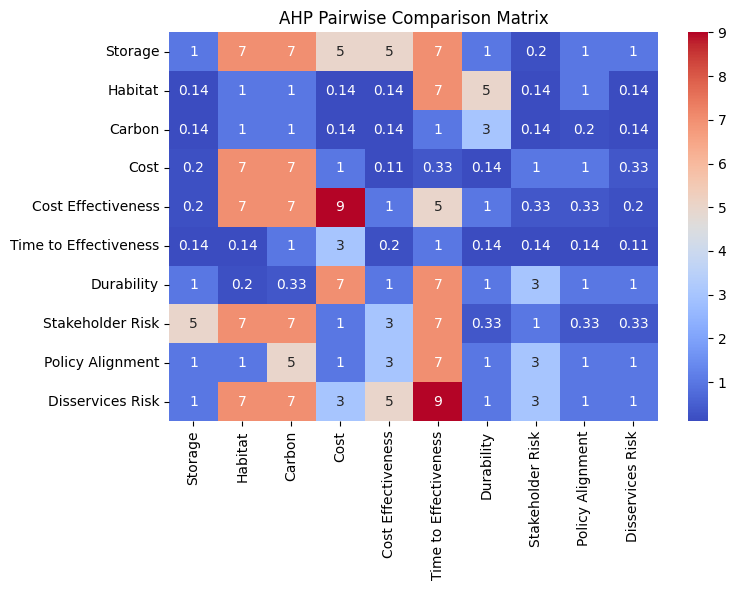

In [11]:
import seaborn as sns # operates alongside matplotlib so that graphs are clearer
# needed for heatmap etc.


if matrix is not None:

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria) #defines graph layout and display

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_matrix, annot=True, cmap="coolwarm") #defines graph choice and style

    plt.title("AHP Pairwise Comparison Matrix")
    plt.tight_layout()
    plt.show()

else:
    print_note("Heatmap skipped — no pairwise matrix available due to route choice.")

**See Output for Understanding here: Criteria Weight Graph**

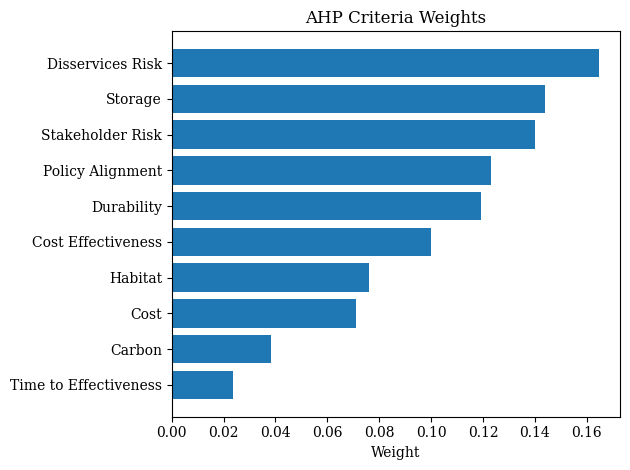

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Sort weights (so highest appears at top)
sorted_indices = np.argsort(weights)
sorted_criteria = [criteria[i] for i in sorted_indices]
sorted_weights = weights[sorted_indices] #sorted by number and size

plt.rcParams["font.family"] = "serif" #to match my dissertation, font can be altered here.
plt.figure() #plots graph

plt.barh(sorted_criteria, sorted_weights)

plt.xlabel("Weight")
plt.title("AHP Criteria Weights")

plt.tight_layout()
plt.show()

In [13]:
interventions = [
    "Large Woody Debris",
    "Tree Planting",
    "Floodplain Reconnection",
    "Wet Woodland",
    "Buffer Strip",
    "Soil Management",
    "Runoff Attenuation Feature",
    "Grip Blocking",
    "Gully Stuffing",
    "Peat Management"
]


## Step 3: NatureInsight Scoring

This stage captures performance scores for each intervention across the defined criteria, representing outputs derived from the ranked NatureInsight values or user-informed interpretation of those outputs.

Scores are assigned on a standardised **1–5 scale, which is custom to each intervention, unless follows a general approach. However, generally it follows this scale:**:
- 1 = Very low performance
- 5 = Very high performance

Users may enter **NA** if data is unavailable . These values are retained as missing data and excluded from aggregation where appropriate.

Uncertain values are shown in grey in the matrix, so **it is important to mark these with 'u'**, opposed to N/a. This is critical in understanding where there is a tool gap, or literature gap.

While default scoring system reflects the structure and intent of NatureInsight outputs, the framework allows for **user modification** to reflect:
- Local knowledge  
- Project-specific priorities  
- Alternative interpretations of intervention performance

# **Changes are welcomed.**

However, any adjustments should remain **grounded in industry guidance, literature, or practitioner judgement**, ensuring that scoring remains realistic, defensible, and comparable. This will also produce more accurate results!

Following, weight calculations are applied to support trade-off discussions.



For the NatureInsight scoring, my recomended approach is to isolate interventions within NatureInsight, and record their total storage. Following, a ranking can be made from 1-10 as to which offers the most storage for your catchment. As this scale is 1-5 to support the literature section, numbers can be halves to fit the scale ie 10 maps to 5 and so forth.

Alternatively, storage per area could be observed, but this is less catchment-specific.

**To note: To support graphical representation, higher rankings are higher performance, in this case. Furthermore,  the case study catchment proposes ten different recomendations, note this could change between catchments and should be considered within these criteria currently**

### Uncertainty Values ("u")

During manual scoring, users may assign a value of **"u"** where evidence is available but confidence in the score is low or the available evidence is ambiguous.

Examples may include:

- Contradictory literature findings.
- Highly site-specific intervention performance.
- Limited quantitative evidence.
- Uncertain transferability between case studies.

When entered, "u" is treated as an uncertainty flag rather than a numerical score.

Within matrix outputs:

| Entry | Meaning | Colour |
|---------|---------|---------|
| u | Evidence available but uncertain | White |
| N/A | No evidence available | Grey |

For weighted calculations, uncertainty values are excluded from scoring and adaptive normalisation is applied to the remaining available criteria. Consequently, interventions containing one or more uncertainty values may still receive an overall weighted score, but this score should be interpreted alongside the detailed matrix outputs.

In [14]:
print("U for uncertain and N/A for unknown")

scoring_guides = {
    "Storage": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Cost": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Habitat": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Carbon": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

   "Cost Effectiveness": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Time to Effectiveness": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Durability": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Stakeholder Risk": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Policy Alignment": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"
    ],

    "Disservices Risk": [
        "1 = Ranks 1 or 2 amongst catchment interventions",
        "2 = Ranks 3 or 4 amongst catchment interventions",
        "3 = Ranks 5 or 6 amongst catchment interventions",
        "4 = Ranks 7 or 8 amongst catchment interventions",
        "5 = Ranks 9 or 10 amongst catchment interventions"]
}


U for uncertain and N/A for unknown


In [15]:

# Nature Insights Scoring

print_subtitle("Nature Insights Scoring")

ni_mode = input(
    "How would you like to provide NI scores?\n"
    "1 - Input manually\n"
    "2 - Upload scoring file\n"
    "Enter 1 or 2: "
).strip()



# OPTION 1: MANUAL INPUT

if ni_mode == "1":

    df_NI = pd.DataFrame(index=interventions, columns=criteria)

    for crit in criteria:
        print_subtitle(f"Scoring: {crit}")

        # Show custom guide if available
        if crit in scoring_guides:
            print("\nScoring guide:")
            for line in scoring_guides[crit]:
                print(line)
        else:
            print("1=Very low | 2=Low | 3=Moderate | 4=High | 5=Very high or enter N/a if no information to score or 'u' for uncertainties")

        print()

        for inter in interventions:
            while True:
                value = input(f"{inter} (1–5 or NA or 'u'): ").strip()

                if value.lower() in ["na", "x"]:
                    df_NI.loc[inter, crit] = np.nan
                    break

                try:
                    val = int(value)
                    if 1 <= val <= 5:
                        df_NI.loc[inter, crit] = val
                        break
                except:
                    pass

                print("Invalid input. Enter 1–5 or NA or 'u'.")

    print("\nNI scoring completed.")



# OPTION 2: UPLOAD FILE

elif ni_mode == "2":

    from google.colab import files
    import io
    import os

    print("\nUpload your NI scoring file:")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    file_ext = os.path.splitext(filename)[1].lower()

    # Read either Excel or CSV
    if file_ext in [".xlsx", ".xls"]:
        df_NI = pd.read_excel(io.BytesIO(uploaded[filename]))
    elif file_ext == ".csv":
        df_NI = pd.read_csv(io.BytesIO(uploaded[filename]))
    else:
        raise ValueError("Unsupported file type. Please upload .xlsx, .xls, or .csv")

    # The rest of the cleaning and standardization will be handled by clean_scoring_table

    print(f"\nFile '{filename}' successfully loaded.")
    print("\nNatureInsight scores:")
    display(df_NI)



------------------------------------------------------------
Nature Insights Scoring
------------------------------------------------------------
How would you like to provide NI scores?
1 - Input manually
2 - Upload scoring file
Enter 1 or 2: 2

Upload your NI scoring file:


Saving Scoring file.xlsx to Scoring file.xlsx

File 'Scoring file.xlsx' successfully loaded.

NatureInsight scores:


,Intervention,Storage,Habitat,Carbon,Cost,Cost Effectiveness
0,Runoff Attenuation Feature,5,3,3,1,4
1,Floodplain Reconnection,5,4,1,2,3
2,Large Woody Debris,4,1,1,1,1
3,Tree Planting,2,5,5,2,1
4,Wet Woodland,4,4,5,3,4
5,Buffer Strips,2,5,4,3,2
6,Soil Management,3,1,4,4,5
7,Gully Stuffing,1,1,1,4,3
8,Grip Blocking,3,3,2,5,5
9,Peat Management,1,2,3,5,2


## Step 4: Literature Scoring and Gap Matrix

This step allows comparison between NatureInsight outputs and literature-based expectations.

Users can:
- Input literature scores manually  
- Upload a scoring dataset  
- Use predefined literature datasets  

Missing values (NA) are supported to reflect uncertainty or lack of evidence.



In [16]:

#  Literature Scoring Option

include_lit = input(
    "\nDo you want to include literature scoring and create a gap matrix? (y/n): "
).strip().lower() # provides the option for further exploration if wanted.

if include_lit == "y":

    print_subtitle("Literature Scoring")

    source_choice = input(
        "Choose literature scoring source:\n"
        "1 - Score yourself\n"
        "2 - Use predefined dataset\n"
        "Enter 1 or 2: "
    ).strip()


    # OPTION 1: USER DEFINES SCORES

    if source_choice == "1":

        method = input(
            "How would you like to provide scores?\n"
            "1 - Manual input\n"
            "2 - Upload scoring file\n"
            "Enter 1 or 2: "
        ).strip()


        # Manual scoring (same as NI)

        if method == "1":

            df_LIT = pd.DataFrame(index=interventions, columns=criteria)

            for crit in criteria:
                print_subtitle(f"Literature Scoring: {crit}")

                if crit in scoring_guides:
                    print("\nScoring guide:")
                    for line in scoring_guides[crit]:
                        print(line)
                else:
                    print("1=Very low | 2=Low | 3=Moderate | 4=High | 5=Very high")

                print("Enter 1–5 or 'NA' for missing data\n")

                for inter in interventions:
                    while True:
                        value = input(f"{inter}: ").strip()

                        if value.lower() in ["na", "x", ""]:
                            df_LIT.loc[inter, crit] = np.nan
                            break

                        try:
                            val = int(value)
                            if 1 <= val <= 5:
                                df_LIT.loc[inter, crit] = val
                                break
                        except:
                            pass

                        print("Invalid input. Enter 1–5 or NA.")

            print("\nLiterature scoring completed.")


        # Upload scoring

        elif method == "2":

            from google.colab import files
            import io
            import os

            print("\nUpload your literature scoring file:")
            uploaded = files.upload()

            filename = list(uploaded.keys())[0]
            file_ext = os.path.splitext(filename)[1].lower()

            if file_ext in [".xlsx", ".xls"]:
                df_LIT = pd.read_excel(io.BytesIO(uploaded[filename]))
            elif file_ext == ".csv":
                df_LIT = pd.read_csv(io.BytesIO(uploaded[filename]))
            else:
                raise ValueError("Unsupported file type. Please upload .xlsx, .xls, or .csv")

            print(f"\nFile '{filename}' successfully loaded.")

        else:
            raise ValueError("Invalid selection.")


    # OPTION 2: PREDEFINED DATASET, made in advance according to NI interventions

    elif source_choice == "2":

        print("\nUsing predefined literature scoring dataset.")

        data = [
    # Storage, Habitat, Carbon, Cost, Cost-Effectiveness,
    # Time, Durability, Stakeholder Risk, Policy, Disservices

    [4, 3, 3, 3, 4, 5, 3, 2, 2, 3],        # Runoff Attenuation Feature
    [5, 5, 5, 1, 3, 5, 4, 1, 3, 2],        # Floodplain Reconnection
    [3, 4, np.nan, 4, 5, 5, 1, 4, 3, 1],   # Large Woody Debris
    [4, 5, 5, 2, 3, 1, 5, 2, 4, 5],        # Tree Planting
    [4, 5, 5, 5, 3, 1, 5, 3, 5, 4],        # Wet Woodland
    [np.nan, 3, 2, 4, 4, 4, 5, 3, 5, 5],   # Buffer Strip
    [np.nan, 2, 2, 4, 4, 3, 4, 5, 5, 5],   # Soil Management
    [5, 5, 5, 2, 3, 2, 5, 3, 4, 5],        # Peat Management
    [1, 4, 2, 4, 3, 5, 1, 4, 3, 1],        # Gully Stuffing
    [4, 4, 4, 2, 3, 3, 4, 4, 4, 4],        # Grip Blocking
]

        df_LIT = pd.DataFrame(data, index=interventions, columns=criteria)

        print_subtitle("Predefined Literature Scores, Please Note this has no gaps, and will vary from sources, which were found to be highly variable in this process")


# ============================================================
# NO LITERATURE

elif include_lit == "n":
    df_LIT = None

else:
    raise ValueError("Invalid input. Enter y or n.")



Do you want to include literature scoring and create a gap matrix? (y/n): y

------------------------------------------------------------
Literature Scoring
------------------------------------------------------------
Choose literature scoring source:
1 - Score yourself
2 - Use predefined dataset
Enter 1 or 2: 2

Using predefined literature scoring dataset.

------------------------------------------------------------
Predefined Literature Scores, Please Note this has no gaps, and will vary from sources, which were found to be highly variable in this process
------------------------------------------------------------


In [17]:

# Clean and align NI / Literature scoring tables
# ------------------------------------------------------------
# This cell standardises uploaded, manual and predefined scoring tables.
# It fixes common mismatches just for clarity. Ideally, this is avoided initially, but it is for precaution.

# The function is safe for:
# 1) uploaded Excel/CSV files with an Intervention column
# 2) uploaded files where the first column contains intervention names
# 3) manual/predefined DataFrames where interventions are already the index

def clean_scoring_table(df, table_name="Scoring table"):
    df = df.copy()


    # Clean column names

    df.columns = df.columns.astype(str).str.strip()

    # Decide whether an intervention column needs setting as index


    intervention_column_options = ["Intervention", "Interventions", "NbS", "NBS", "Nature-based Solution"]

    found_intervention_col = None
    for col in intervention_column_options:
        if col in df.columns:
            found_intervention_col = col
            break

    if found_intervention_col is not None:
        df = df.set_index(found_intervention_col)

    elif isinstance(df.index, pd.RangeIndex):
        # If the index is just 0,1,2..., assume the first column holds intervention names
        first_col = df.columns[0]

        # Only use the first column as index if it is not clearly one of the criteria
        if first_col not in criteria:
            df = df.set_index(first_col)


    # Clean intervention names

    df.index = df.index.astype(str).str.strip()

    intervention_aliases = {
        "RAF": "Runoff Attenuation Feature",
        "RAFs": "Runoff Attenuation Feature",
        "RAF (Bunds/Ponds)": "Runoff Attenuation Feature",
        "Runoff Attenuation Features": "Runoff Attenuation Feature",
        "Runoff Attenuation Feature": "Runoff Attenuation Feature",

        "Floodplain Reconn.": "Floodplain Reconnection",
        "Floodplain Reconn": "Floodplain Reconnection",
        "Floodplain reconnection": "Floodplain Reconnection",
        "Floodplain Reconnection": "Floodplain Reconnection",

        "LWD": "Large Woody Debris",
        "Large Woody Debris": "Large Woody Debris",

        "Tree Plant": "Tree Planting",
        "Tree Planting": "Tree Planting",

        "Wet Wood": "Wet Woodland",
        "Wet Woodland": "Wet Woodland",

        "Buffer Strips": "Buffer Strip",
        "Buffer Strip": "Buffer Strip",

        "Soil Management": "Soil Management",
        "Peat Management": "Peat Management",
        "Gully Stuffing": "Gully Stuffing",
        "Grip Blocking": "Grip Blocking",
    }

    df.index = df.index.map(lambda x: intervention_aliases.get(x, x))

    #  Standardise names

    criterion_aliases = {
        "Cost (Setup)": "Cost",
        "Cost Setup": "Cost",
        "Setup Cost": "Cost",

        "Cost-Effectiveness": "Cost Effectiveness",
        "Cost effectiveness": "Cost Effectiveness",
        "Cost Effectiveness": "Cost Effectiveness",

        "Time": "Time to Effectiveness",
        "Time to effectiveness": "Time to Effectiveness",
        "Time to Effectiveness": "Time to Effectiveness",

        "Policy": "Policy Alignment",
        "Policy alignment": "Policy Alignment",
        "Policy Alignment": "Policy Alignment",

        "Disservices": "Disservices Risk",
        "Disservice Risk": "Disservices Risk",
        "Disservices Risk": "Disservices Risk",

        "Stakeholder risk": "Stakeholder Risk",
        "Stakeholder Risk": "Stakeholder Risk",
    }

    df = df.rename(columns=criterion_aliases)

    #  Replace uncertainty / missing values

    df = df.replace(["NA", "N/A", "na", "n/a", "u", "U", "uncertain", "Uncertain", "", " "], np.nan)

    df = df.reindex(index=interventions, columns=criteria)


    # Convert all score values to numeric

    df = df.apply(pd.to_numeric, errors="coerce")


    print(f"\n{table_name} loaded and cleaned.")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

    missing_by_column = df.isna().sum()
    if missing_by_column.sum() > 0:
        print("\nMissing values by criterion:")
        print(missing_by_column[missing_by_column > 0])

    return df


# Apply the same cleaning function to both datasets
df_NI_num = clean_scoring_table(df_NI, table_name="NatureInsight table")

if df_LIT is not None:
    df_LIT_num = clean_scoring_table(df_LIT, table_name="Literature table")
else:
    df_LIT_num = None



NatureInsight table loaded and cleaned.
Rows: 10, Columns: 10

Missing values by criterion:
Time to Effectiveness    10
Durability               10
Stakeholder Risk         10
Policy Alignment         10
Disservices Risk         10
dtype: int64

Literature table loaded and cleaned.
Rows: 10, Columns: 10

Missing values by criterion:
Storage    2
Carbon     1
dtype: int64


In [18]:
print("\nInterventions loaded:")
print(df_NI_num.index.tolist())

print("\nCriteria loaded:")
print(df_NI_num.columns.tolist())


Interventions loaded:
['Large Woody Debris', 'Tree Planting', 'Floodplain Reconnection', 'Wet Woodland', 'Buffer Strip', 'Soil Management', 'Runoff Attenuation Feature', 'Grip Blocking', 'Gully Stuffing', 'Peat Management']

Criteria loaded:
['Storage', 'Habitat', 'Carbon', 'Cost', 'Cost Effectiveness', 'Time to Effectiveness', 'Durability', 'Stakeholder Risk', 'Policy Alignment', 'Disservices Risk']


In [19]:
#confirm correct weighting score before proceeding
# Use weighting route selected earlier

print_subtitle("Weighting Source")

if route == "1":
    print("Using preset weighting selected earlier.")

elif route == "2":
    print("Using uploaded weighting or pairwise matrix selected earlier.")

elif route == "3":
    print("Using AHP weighting created earlier.")

else:
    raise ValueError("Invalid route selected earlier.")


------------------------------------------------------------
Weighting Source
------------------------------------------------------------
Using uploaded weighting or pairwise matrix selected earlier.


# **Weight outputted here as a check point.**

In [20]:
weights

array([0.14389644, 0.07613344, 0.03834677, 0.07100183, 0.09996404,
       0.02345516, 0.11927947, 0.1402481 , 0.12307834, 0.16459641])

In [21]:
# Apply weights with adaptive normalisation

def weighted_score(row, weights):
    # Converts each intervention row into a weighted score.
    # Missing values are ignored and the remaining weights are re-normalised.
    row = np.array(row, dtype=float)
    mask = ~np.isnan(row)

    if np.sum(mask) == 0:
        return np.nan

    return np.sum(row[mask] * weights[mask]) / np.sum(weights[mask])


# **Step 5: Weighted Comparison and Gap Analysis**

This stage integrates NatureInsight (NI) scoring and literature-based scoring to enable direct comparison between tool outputs and expected performance.

Two outputs are produced:

- **Detailed comparison table**  
  Shows NI scores, literature scores, and criterion-level gaps  

- **Weighted summary table**  
  Aggregates results using AHP-derived weights to produce:
  - NI performance score  
  - Literature benchmark score  
  - Gap score (NI vs Literature)  

Missing values are handled using adaptive normalisation, ensuring results remain robust where data is incomplete.

This enables identification of where NatureInsight may overestimate or underestimate intervention performance. Also, it identifies where gaps, unknowns and uncertains exist.



In [22]:
# Create comparison and weighted summary tables

# df_NI_num and df_LIT_num have already been cleaned and standardised.
# This cell creates the core outputs used later in the notebook.

# Create the detailed comparison matrix
if df_LIT_num is not None:
    df_compare = pd.DataFrame(index=interventions)

    for crit in criteria:
        ni_vals = df_NI_num[crit]
        lit_vals = df_LIT_num[crit]

        # Gap is the absolute difference between NI and Literature.
        # It is not weighted because it represents agreement / disagreement.
        gap_vals = (ni_vals - lit_vals).abs()

        df_compare[f"{crit} NI"] = ni_vals
        df_compare[f"{crit} Lit"] = lit_vals
        df_compare[f"{crit} Gap"] = gap_vals

else:
    # If no literature table is used, only NI scores are shown.
    df_compare = df_NI_num.copy()


# Create the weighted summary table
df_summary = pd.DataFrame(index=interventions)

# NI weighted score
df_summary["NI Weighted Score"] = df_NI_num.apply(
    lambda row: weighted_score(row.values, weights),
    axis=1
)

# Literature weighted score and weighted gap
if df_LIT_num is not None:
    df_summary["Literature Weighted Score"] = df_LIT_num.apply(
        lambda row: weighted_score(row.values, weights),
        axis=1
    )

    # Weighted Gap is the difference between the final weighted NI and Literature scores.
    # This keeps the gap as a comparison measure, rather than weighting the criterion-level gaps.
    df_summary["Weighted Gap"] = (
        df_summary["NI Weighted Score"]
        - df_summary["Literature Weighted Score"]
    ).abs()

# Rank by NI weighted score
df_summary["Rank"] = df_summary["NI Weighted Score"].rank(
    ascending=False,
    method="dense",
    na_option="bottom"
).astype(int)

# Round final tables for cleaner outputs
df_compare = df_compare.round(3)
df_summary = df_summary.round(3)

print_subtitle("Comparison and weighted summary tables created")
print("Final outputs are produced in the sections below.")



------------------------------------------------------------
Comparison and weighted summary tables created
------------------------------------------------------------
Final outputs are produced in the sections below.


# **Output: Cleaner table of comaprisons**

The following tables present the final outputs of the analysis:

- **Detailed Comparison Table**  
  Displays criterion-level scores for NatureInsight (NI) and literature, alongside calculated gaps.

- **Weighted Summary Table**  
  Provides aggregated scores using AHP-derived weights, including:
  - NI performance
  - Literature benchmark (if available)
  - Weighted gap
  - Overall ranking

Results are sorted by weighted score to highlight the highest-performing interventions.

In [25]:
import pandas as pd

# Create a viewable trade-off matrix in the notebook

df_compare_display = df_compare.copy()

# Remove decimals and show missing values clearly
for col in df_compare_display.columns:
    df_compare_display[col] = df_compare_display[col].apply(
        lambda x: "NaN" if pd.isna(x) else int(x)
    )

# Identify gap columns
gap_cols = [c for c in df_compare_display.columns if "Gap" in c]

# Colour only the gap columns
def colour_gap_only(val):
    if pd.isna(val) or val == "NaN":
        return (
            "background-color: #BFBFBF; color: black;"
            "font-style: italic;"
            "font-weight: bold;"
        )

    val = float(val)

    if val == 0:
        return "background-color: #38761D; color: white; font-weight: bold;"
    elif val == 1:
        return "background-color: #B6D7A8; color: black; font-weight: bold;"
    elif val == 2:
        return "background-color: white; color: black; font-weight: bold;"
    elif val == 3:
        return "background-color: #F4CCCC; color: black; font-weight: bold;"
    else:
        return "background-color: #C00000; color: white; font-weight: bold;"

# Keep non-gap cells plain and readable
def base_table_style(val):
    return "background-color: #F7F7F7; color: black;"

styled_matrix = (
    df_compare_display.style
    .map(base_table_style)
    .map(colour_gap_only, subset=gap_cols)
    .set_properties(**{
        "border": "1px solid #D9D9D9",
        "text-align": "center",
        "font-size": "11pt",
        "padding": "6px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid white")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "14pt"),
                ("font-weight", "bold"),
                ("color", "black"),
                ("text-align", "left")
            ]
        }
    ])
    .set_caption("NatureInsight–Literature Trade-Off Matrix")
)

display(styled_matrix)

,Storage NI,Storage Lit,Storage Gap,Habitat NI,Habitat Lit,Habitat Gap,Carbon NI,Carbon Lit,Carbon Gap,Cost NI,Cost Lit,Cost Gap,Cost Effectiveness NI,Cost Effectiveness Lit,Cost Effectiveness Gap,Time to Effectiveness NI,Time to Effectiveness Lit,Time to Effectiveness Gap,Durability NI,Durability Lit,Durability Gap,Stakeholder Risk NI,Stakeholder Risk Lit,Stakeholder Risk Gap,Policy Alignment NI,Policy Alignment Lit,Policy Alignment Gap,Disservices Risk NI,Disservices Risk Lit,Disservices Risk Gap
Large Woody Debris,4,4,0,1,3,2,1,3,2,1,3,2,1,4,3,NaN,5,NaN,NaN,3,NaN,NaN,2,NaN,NaN,2,NaN,NaN,3,NaN
Tree Planting,2,5,3,5,5,0,5,5,0,2,1,1,1,3,2,NaN,5,NaN,NaN,4,NaN,NaN,1,NaN,NaN,3,NaN,NaN,2,NaN
Floodplain Reconnection,5,3,2,4,4,0,1,NaN,NaN,2,4,2,3,5,2,NaN,5,NaN,NaN,1,NaN,NaN,4,NaN,NaN,3,NaN,NaN,1,NaN
Wet Woodland,4,4,0,4,5,1,5,5,0,3,2,1,4,3,1,NaN,1,NaN,NaN,5,NaN,NaN,2,NaN,NaN,4,NaN,NaN,5,NaN
Buffer Strip,2,4,2,5,5,0,4,5,1,3,5,2,2,3,1,NaN,1,NaN,NaN,5,NaN,NaN,3,NaN,NaN,5,NaN,NaN,4,NaN
Soil Management,3,NaN,NaN,1,3,2,4,2,2,4,4,0,5,4,1,NaN,4,NaN,NaN,5,NaN,NaN,3,NaN,NaN,5,NaN,NaN,5,NaN
Runoff Attenuation Feature,5,NaN,NaN,3,2,1,3,2,1,1,4,3,4,4,0,NaN,3,NaN,NaN,4,NaN,NaN,5,NaN,NaN,5,NaN,NaN,5,NaN
Grip Blocking,3,5,2,3,5,2,2,5,3,5,2,3,5,3,2,NaN,2,NaN,NaN,5,NaN,NaN,3,NaN,NaN,4,NaN,NaN,5,NaN
Gully Stuffing,1,1,0,1,4,3,1,2,1,4,4,0,3,3,0,NaN,5,NaN,NaN,1,NaN,NaN,4,NaN,NaN,3,NaN,NaN,1,NaN
Peat Management,1,4,3,2,4,2,3,4,1,5,2,3,2,3,1,NaN,3,NaN,NaN,4,NaN,NaN,4,NaN,NaN,4,NaN,NaN,4,NaN


### Gap Scores

Gap scores represent the absolute difference between NatureInsight and Literature values:

Gap = |NI − Literature|

The gap is not weighted, as it represents agreement between evidence sources rather than intervention performance.

| Gap | Interpretation | Colour |
|---------|---------|---------|
| 0 | Strong agreement | Dark Green |
| 1 | Close agreement | Light Green |
| 2 | Moderate uncertainty / fuzzy relationship | White |
| 3 | Significant disagreement | Orange |
| 4+ | Major disagreement | Red |
| N/A | No information available | Grey |

## How to Interpret the Matrix

A strong intervention is not necessarily the one with the highest score in one category. Instead, decision-making should consider:

- consistently high NI and literature scores
- low gap values, suggesting stronger confidence
- high weighted summary scores
- whether disagreement occurs in critical criteria such as storage, cost or delivery risk
- whether an intervention performs well across multiple benefits, rather than only one

Large gap values should be treated with caution. They do not automatically mean an intervention is unsuitable, but they indicate where further investigation, site-specific evidence or stakeholder review may be needed.

# Below will Download A Readable and Sharable Matrix

In [23]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from google.colab import files

# Create a readable Excel version of the trade-off matrix

# Copy final comparison table
df_export = df_compare.copy()

# Display missing values clearly
for col in df_export.columns:
    df_export[col] = df_export[col].apply(
        lambda x: "NaN" if pd.isna(x) else int(x)
    )

# Create workbook
wb = Workbook()
ws = wb.active
ws.title = "Trade-Off Matrix"

# Add title
ws.cell(row=1, column=1, value="NatureInsight–Literature Trade-Off Matrix")
ws.cell(row=1, column=1).font = Font(bold=True, size=14)
ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=len(df_export.columns) + 1)

# Add first column header
ws.cell(row=3, column=1, value="Intervention")
ws.merge_cells(start_row=3, start_column=1, end_row=4, end_column=1)

# Add grouped headers
current_col = 2

if df_LIT_num is not None:
    for crit in criteria:
        ws.cell(row=3, column=current_col, value=crit)
        ws.merge_cells(start_row=3, start_column=current_col, end_row=3, end_column=current_col + 2)

        ws.cell(row=4, column=current_col, value="NI")
        ws.cell(row=4, column=current_col + 1, value="Lit")
        ws.cell(row=4, column=current_col + 2, value="Gap")

        current_col += 3
else:
    for crit in criteria:
        ws.cell(row=3, column=current_col, value=crit)
        ws.cell(row=4, column=current_col, value="NI")
        current_col += 1

# Add data
start_row = 5

for r, intervention in enumerate(df_export.index, start=start_row):
    ws.cell(row=r, column=1, value=intervention)

    for c, value in enumerate(df_export.loc[intervention], start=2):
        ws.cell(row=r, column=c, value=value)

# Colours
blue = "1F4E79"
sub_blue = "D9E2F3"
off_white = "F7F7F7"
grey = "BFBFBF"
dark_green = "38761D"
light_green = "B6D7A8"
white = "FFFFFF"
light_red = "F4CCCC"
dark_red = "C00000"

thin = Side(style="thin", color="D9D9D9")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

# Style headers and body
for row in ws.iter_rows(min_row=1, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
    for cell in row:
        cell.border = border
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# Title
ws.cell(row=1, column=1).alignment = Alignment(horizontal="left", vertical="center")

# Header rows
for cell in ws[3]:
    cell.fill = PatternFill("solid", fgColor=blue)
    cell.font = Font(color="FFFFFF", bold=True)

for cell in ws[4]:
    cell.fill = PatternFill("solid", fgColor=sub_blue)
    cell.font = Font(bold=True)

# Body
for row in ws.iter_rows(min_row=5, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
    for cell in row:
        cell.fill = PatternFill("solid", fgColor=off_white)

# Intervention names
for row in range(5, ws.max_row + 1):
    ws.cell(row=row, column=1).font = Font(bold=True)
    ws.cell(row=row, column=1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)

# Colour gap columns only
for c in range(2, ws.max_column + 1):
    score_type = ws.cell(row=4, column=c).value

    if score_type == "Gap":
        for r in range(5, ws.max_row + 1):
            cell = ws.cell(row=r, column=c)
            val = cell.value
            cell.font = Font(bold=True)

            if val == "NaN":
                cell.fill = PatternFill("solid", fgColor=grey)
                cell.font = Font(italic=True, bold=True)

            elif val == 0:
                cell.fill = PatternFill("solid", fgColor=dark_green)
                cell.font = Font(color="FFFFFF", bold=True)

            elif val == 1:
                cell.fill = PatternFill("solid", fgColor=light_green)
                cell.font = Font(bold=True)

            elif val == 2:
                cell.fill = PatternFill("solid", fgColor=white)
                cell.font = Font(bold=True)

            elif val == 3:
                cell.fill = PatternFill("solid", fgColor=light_red)
                cell.font = Font(bold=True)

            else:
                cell.fill = PatternFill("solid", fgColor=dark_red)
                cell.font = Font(color="FFFFFF", bold=True)

# Column widths
ws.column_dimensions["A"].width = 32

for c in range(2, ws.max_column + 1):
    ws.column_dimensions[get_column_letter(c)].width = 11

# Header row heights
ws.row_dimensions[3].height = 34
ws.row_dimensions[4].height = 22

# Freeze panes
ws.freeze_panes = "B5"

# Save and download
output_file = "NatureInsight_Literature_TradeOff_Matrix_Formatted.xlsx"
wb.save(output_file)

files.download(output_file)

print(f"Saved: {output_file}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: NatureInsight_Literature_TradeOff_Matrix_Formatted.xlsx


## Weighted Intervention Ranking

The weighted ranking table translates the detailed trade-off matrix into a single decision-support output.

Whereas the matrix highlights individual strengths, weaknesses, uncertainties and evidence gaps, the weighted ranking combines all available criteria using the user-defined Analytic Hierarchy Process (AHP) weightings. This enables interventions to be assessed according to the priorities of a specific project, organisation or stakeholder group.

### How the Ranking is Calculated

The overall score is calculated using the selected AHP weights and the available intervention scores.

Adaptive normalisation is applied where criteria contain missing values (NaN). This ensures interventions are not unfairly penalised where information is unavailable, with the remaining criteria re-scaled proportionally.

The weighted ranking therefore reflects:

- Relative intervention performance.
- User-defined priorities.
- Available evidence.
- Trade-offs between competing objectives.

### Interpretation

Higher weighted scores indicate stronger overall performance against the selected priorities.

However, a high ranking should not automatically be interpreted as a recommendation for implementation. The weighted score should always be interpreted alongside the detailed trade-off matrix to understand:

- Areas of uncertainty.
- Evidence gaps.
- Disagreement between NatureInsight and literature.
- Potential implementation constraints.
- Context-specific limitations.

### Assumptions and Limitations

Several assumptions will influence the weighted ranking:

- Literature scores are derived from published evidence and therefore remain subject to interpretation.
- Intervention performance is simplified into ordinal scores (1–5), whereas in reality, it is not so simple.
- Criteria are assumed to be independent.
- Missing information is excluded through adaptive normalisation.
- Site-specific constraints and context may not be fully represented.
- Weightings reflect user judgement and may vary substantially between stakeholders.

Consequently, the weighted ranking should be interpreted as a structured decision-support output rather than a definitive decision-making tool. However, the stronger the evidence base for the inputs, the more reliable the outcome is

In [24]:
# Create a clean weighted ranking table for presentation

# Copy the weighted summary table
weighted_table = df_summary.copy()

# Round score columns to 2 decimal places
score_cols = [
    "NI Weighted Score",
    "Literature Weighted Score",
    "Weighted Gap"
]

for col in score_cols:
    if col in weighted_table.columns:
        weighted_table[col] = weighted_table[col].round(2)

# Make rank a whole number
weighted_table["Rank"] = weighted_table["Rank"].astype(int)

# Sort by NI weighted score
weighted_table = weighted_table.sort_values(
    by="NI Weighted Score",
    ascending=False
)

# Display as a clean table
print("Weighted Intervention Ranking")
display(weighted_table)

# Save the weighted table
weighted_output_file = "Weighted_Intervention_Ranking.xlsx"
weighted_table.to_excel(weighted_output_file)

print(f"Saved: {weighted_output_file}")


Weighted Intervention Ranking


,NI Weighted Score,Literature Weighted Score,Weighted Gap,Rank
Wet Woodland,3.92,3.81,0.12,1
Grip Blocking,3.71,4.11,0.41,2
Runoff Attenuation Feature,3.57,4.20,0.63,3
Floodplain Reconnection,3.50,2.96,0.54,4
Soil Management,3.37,4.13,0.77,5
Buffer Strip,2.88,4.12,1.24,6
Tree Planting,2.57,3.10,0.53,7
Peat Management,2.25,3.74,1.48,8
Large Woody Debris,2.00,3.03,1.02,9
Gully Stuffing,1.96,2.44,0.48,10


Saved: Weighted_Intervention_Ranking.xlsx


Within my study, I proposed the integration of developing this trade-off idea into a cocept "BRITE-NI", (Budget-Responsive Intervention and Trade-off Evaluation for NatureInsight) extends NatureInsight outputs by introducing a transparent trade-off and prioritisation framework.

The workflow:

1. Is initially confined with a budget
2. NI outputs respond to this budget
3. In-field analysis utilised to gauge a realism index, to indicate barriers to implementation
4. This trade-off matrix strengthened and then used to support decision making further.

The key benefits of the matrix, and its design are:

- Clear disagreements in NI and literature, to encourage questions in decisions and reliability
- Indicate where NI assumptions may introduce weaknesses
- clearly demonstrates where there is uncertainty and gaps in both the tool, and literature. Again, this indicates where caution is necessary.
- Reflects stakeholder views through weightings.
- Supports movement towards implementation.



The outputs should be used as decision-support tools rather than definitive recommendations, helping practitioners understand trade-offs, assumptions and evidence confidence before implementation.



